<a href="https://colab.research.google.com/github/suflorian-commits/modeling_project/blob/main/evaluation/evaluation_binary.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
# necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
    precision_recall_curve
)

MODEL PERFORMANCE METRICS
Accuracy:     0.840
Precision:    0.484  (Of predicted rain, 48.4% was correct)
Recall:       0.673  (Caught 67.3% of actual rain events)
F1 Score:     0.563
Specificity:  0.870  (Correct no-rain predictions)
False Alarm:  0.130  (13.0% of no-rain times incorrectly predicted)

Total predictions: 1000
Actual rain events: 153 (15.3%)
Predicted rain events: 213 (21.3%)

Figure saved to: model_evaluation.png


/tmp/ipython-input-580600499.py:234: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


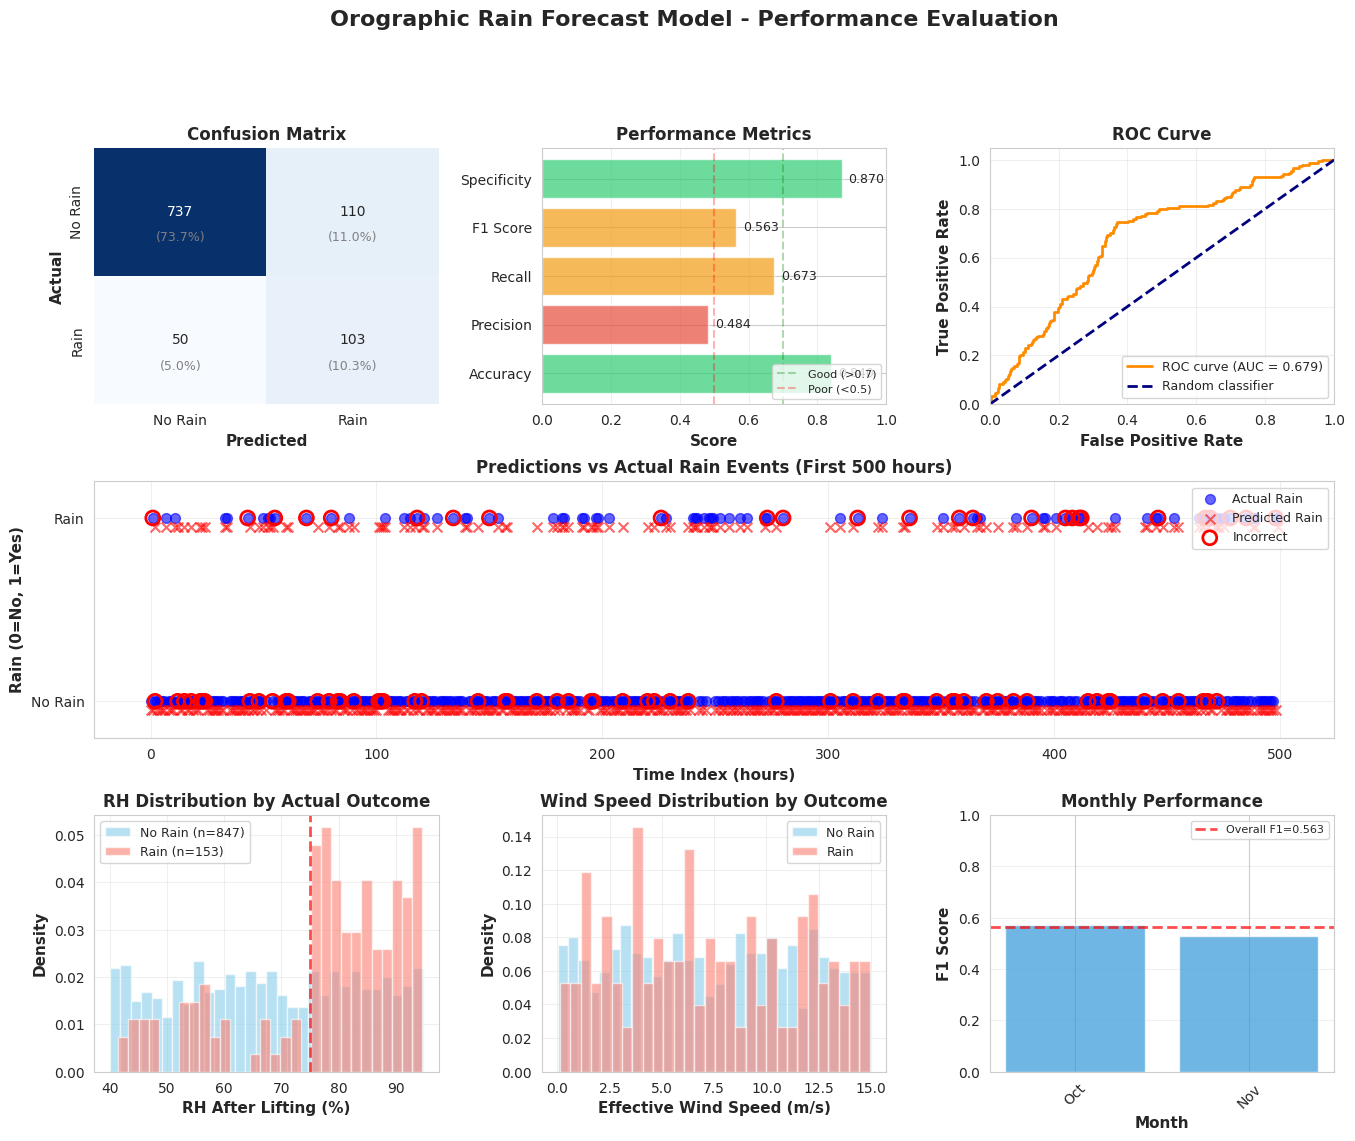


EVALUATION COMPLETE


In [ ]:
# Draft for Visualizations
# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 10)

def evaluate_and_visualize_model(results_df, save_path=None):
    """
    Comprehensive evaluation and visualization of the orographic rain forecast model.

    Parameters:
    -----------
    results_df : pandas.DataFrame
        DataFrame with columns: 'timestamp_dest', 'rain_forecast', 'rain_actual',
                                'rh_lifted', 'u_effective', 'lag_hours'
    save_path : str, optional
        Path to save the figure

    Returns:
    --------
    metrics : dict
        Dictionary containing all performance metrics
    """

    # Extract predictions and actual values
    y_pred = results_df['rain_forecast'].values
    y_true = results_df['rain_actual'].values
    rh_lifted = results_df['rh_lifted'].values

    # Calculate metrics
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    accuracy = (tp + tn) / (tp + tn + fp + fn)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

    # False alarm rate
    far = fp / (fp + tn) if (fp + tn) > 0 else 0

    # Print metrics
    print("=" * 60)
    print("MODEL PERFORMANCE METRICS")
    print("=" * 60)
    print(f"Accuracy:     {accuracy:.3f}")
    print(f"Precision:    {precision:.3f}  (Of predicted rain, {precision*100:.1f}% was correct)")
    print(f"Recall:       {recall:.3f}  (Caught {recall*100:.1f}% of actual rain events)")
    print(f"F1 Score:     {f1:.3f}")
    print(f"Specificity:  {specificity:.3f}  (Correct no-rain predictions)")
    print(f"False Alarm:  {far:.3f}  ({far*100:.1f}% of no-rain times incorrectly predicted)")
    print("=" * 60)
    print(f"\nTotal predictions: {len(y_true)}")
    print(f"Actual rain events: {np.sum(y_true)} ({np.sum(y_true)/len(y_true)*100:.1f}%)")
    print(f"Predicted rain events: {np.sum(y_pred)} ({np.sum(y_pred)/len(y_pred)*100:.1f}%)")
    print("=" * 60)

    # Create comprehensive visualization
    fig = plt.figure(figsize=(16, 12))
    gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

    # 1. Confusion Matrix
    ax1 = fig.add_subplot(gs[0, 0])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax1,
                xticklabels=['No Rain', 'Rain'],
                yticklabels=['No Rain', 'Rain'])
    ax1.set_xlabel('Predicted', fontsize=11, fontweight='bold')
    ax1.set_ylabel('Actual', fontsize=11, fontweight='bold')
    ax1.set_title('Confusion Matrix', fontsize=12, fontweight='bold')

    # Add percentage annotations
    total = np.sum(cm)
    for i in range(2):
        for j in range(2):
            pct = cm[i, j] / total * 100
            ax1.text(j + 0.5, i + 0.7, f'({pct:.1f}%)',
                    ha='center', va='center', fontsize=9, color='gray')

    # 2. Performance Metrics Bar Chart
    ax2 = fig.add_subplot(gs[0, 1])
    metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'Specificity']
    metrics_values = [accuracy, precision, recall, f1, specificity]
    colors = ['#2ecc71' if m > 0.7 else '#e74c3c' if m < 0.5 else '#f39c12'
              for m in metrics_values]

    bars = ax2.barh(metrics_names, metrics_values, color=colors, alpha=0.7)
    ax2.set_xlim([0, 1])
    ax2.set_xlabel('Score', fontsize=11, fontweight='bold')
    ax2.set_title('Performance Metrics', fontsize=12, fontweight='bold')
    ax2.axvline(x=0.7, color='green', linestyle='--', alpha=0.3, label='Good (>0.7)')
    ax2.axvline(x=0.5, color='red', linestyle='--', alpha=0.3, label='Poor (<0.5)')

    # Add value labels
    for i, (bar, val) in enumerate(zip(bars, metrics_values)):
        ax2.text(val + 0.02, i, f'{val:.3f}', va='center', fontsize=9)

    ax2.legend(fontsize=8, loc='lower right')
    ax2.grid(axis='x', alpha=0.3)

    # 3. ROC Curve using RH_lifted as probability score
    ax3 = fig.add_subplot(gs[0, 2])

    # Normalize RH_lifted to [0, 1] for ROC curve
    rh_normalized = (rh_lifted - rh_lifted.min()) / (rh_lifted.max() - rh_lifted.min())
    fpr, tpr, thresholds = roc_curve(y_true, rh_normalized)
    roc_auc = auc(fpr, tpr)

    ax3.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
    ax3.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random classifier')
    ax3.set_xlim([0.0, 1.0])
    ax3.set_ylim([0.0, 1.05])
    ax3.set_xlabel('False Positive Rate', fontsize=11, fontweight='bold')
    ax3.set_ylabel('True Positive Rate', fontsize=11, fontweight='bold')
    ax3.set_title('ROC Curve', fontsize=12, fontweight='bold')
    ax3.legend(loc="lower right", fontsize=9)
    ax3.grid(alpha=0.3)

    # 4. Time Series: Predictions vs Actual
    ax4 = fig.add_subplot(gs[1, :])

    # Plot first 500 hours for visibility (adjust as needed)
    plot_length = min(500, len(results_df))
    time_range = range(plot_length)

    ax4.scatter(time_range, y_true[:plot_length], marker='o', s=50,
               color='blue', alpha=0.6, label='Actual Rain', zorder=3)
    ax4.scatter(time_range, y_pred[:plot_length] - 0.05, marker='x', s=50,
               color='red', alpha=0.6, label='Predicted Rain', zorder=3)

    # Highlight correct and incorrect predictions
    correct = (y_pred[:plot_length] == y_true[:plot_length])
    incorrect = ~correct

    ax4.scatter(np.array(time_range)[incorrect], y_true[:plot_length][incorrect],
               marker='o', s=100, facecolors='none', edgecolors='red',
               linewidths=2, label='Incorrect', zorder=4)

    ax4.set_ylim([-0.2, 1.2])
    ax4.set_xlabel('Time Index (hours)', fontsize=11, fontweight='bold')
    ax4.set_ylabel('Rain (0=No, 1=Yes)', fontsize=11, fontweight='bold')
    ax4.set_title('Predictions vs Actual Rain Events (First 500 hours)',
                 fontsize=12, fontweight='bold')
    ax4.legend(loc='upper right', fontsize=9)
    ax4.grid(alpha=0.3)
    ax4.set_yticks([0, 1])
    ax4.set_yticklabels(['No Rain', 'Rain'])

    # 5. RH_lifted Distribution by Outcome
    ax5 = fig.add_subplot(gs[2, 0])

    rh_no_rain_actual = rh_lifted[y_true == 0]
    rh_rain_actual = rh_lifted[y_true == 1]

    ax5.hist(rh_no_rain_actual, bins=30, alpha=0.6, color='skyblue',
            label=f'No Rain (n={len(rh_no_rain_actual)})', density=True)
    ax5.hist(rh_rain_actual, bins=30, alpha=0.6, color='salmon',
            label=f'Rain (n={len(rh_rain_actual)})', density=True)

    ax5.set_xlabel('RH After Lifting (%)', fontsize=11, fontweight='bold')
    ax5.set_ylabel('Density', fontsize=11, fontweight='bold')
    ax5.set_title('RH Distribution by Actual Outcome', fontsize=12, fontweight='bold')
    ax5.legend(fontsize=9)
    ax5.grid(alpha=0.3)
    ax5.axvline(x=75, color='red', linestyle='--', linewidth=2,
               label='Threshold (γ=0.75)', alpha=0.7)

    # 6. Effective Wind Speed Distribution
    ax6 = fig.add_subplot(gs[2, 1])

    u_eff = results_df['u_effective'].values
    u_eff_rain = u_eff[y_true == 1]
    u_eff_no_rain = u_eff[y_true == 0]

    ax6.hist(u_eff_no_rain, bins=30, alpha=0.6, color='skyblue',
            label=f'No Rain', density=True)
    ax6.hist(u_eff_rain, bins=30, alpha=0.6, color='salmon',
            label=f'Rain', density=True)

    ax6.set_xlabel('Effective Wind Speed (m/s)', fontsize=11, fontweight='bold')
    ax6.set_ylabel('Density', fontsize=11, fontweight='bold')
    ax6.set_title('Wind Speed Distribution by Outcome', fontsize=12, fontweight='bold')
    ax6.legend(fontsize=9)
    ax6.grid(alpha=0.3)

    # 7. Monthly Performance (if timestamp available)
    ax7 = fig.add_subplot(gs[2, 2])

    if 'timestamp_dest' in results_df.columns:
        results_df['month'] = pd.to_datetime(results_df['timestamp_dest']).dt.month

        monthly_f1 = []
        months = []

        for month in range(1, 13):
            month_data = results_df[results_df['month'] == month]
            if len(month_data) > 0:
                y_true_m = month_data['rain_actual'].values
                y_pred_m = month_data['rain_forecast'].values

                tp_m = np.sum((y_true_m == 1) & (y_pred_m == 1))
                fp_m = np.sum((y_true_m == 0) & (y_pred_m == 1))
                fn_m = np.sum((y_true_m == 1) & (y_pred_m == 0))

                prec_m = tp_m / (tp_m + fp_m) if (tp_m + fp_m) > 0 else 0
                rec_m = tp_m / (tp_m + fn_m) if (tp_m + fn_m) > 0 else 0
                f1_m = 2 * (prec_m * rec_m) / (prec_m + rec_m) if (prec_m + rec_m) > 0 else 0

                monthly_f1.append(f1_m)
                months.append(month)

        month_names = ['Oct', 'Nov', 'Dec','Jan', 'Feb', 'Mar']

        colors_monthly = ['#3498db' if m in [10, 11, 12, 1, 2, 3] else '#95a5a6'
                         for m in months]

        ax7.bar([month_names[m-1] for m in months], monthly_f1,
               color=colors_monthly, alpha=0.7)
        ax7.set_xlabel('Month', fontsize=11, fontweight='bold')
        ax7.set_ylabel('F1 Score', fontsize=11, fontweight='bold')
        ax7.set_title('Monthly Performance', fontsize=12, fontweight='bold')
        ax7.axhline(y=f1, color='red', linestyle='--', linewidth=2,
                   label=f'Overall F1={f1:.3f}', alpha=0.7)
        ax7.legend(fontsize=8)
        ax7.grid(axis='y', alpha=0.3)
        ax7.set_ylim([0, 1])
        plt.setp(ax7.xaxis.get_majorticklabels(), rotation=45)

    plt.suptitle('Orographic Rain Forecast Model - Performance Evaluation',
                fontsize=16, fontweight='bold', y=0.995)

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"\nFigure saved to: {save_path}")

    plt.tight_layout()
    plt.show()

    # Return metrics dictionary
    metrics = {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'specificity': specificity,
        'false_alarm_rate': far,
        'confusion_matrix': cm,
        'roc_auc': roc_auc,
        'true_positives': tp,
        'false_positives': fp,
        'true_negatives': tn,
        'false_negatives': fn
    }

    return metrics


# Example usage:
if __name__ == "__main__":
    # Generate synthetic example data for demonstration
    np.random.seed(42)
    n_samples = 1000

    # Simulate model results
    example_results = pd.DataFrame({
        'timestamp_dest': pd.date_range('2023-01-01', periods=n_samples, freq='h'),
        'rain_actual': np.random.choice([0, 1], size=n_samples, p=[0.85, 0.15]),
        'rain_forecast': np.random.choice([0, 1], size=n_samples, p=[0.87, 0.13]),
        'rh_lifted': np.random.uniform(40, 95, size=n_samples),
        'u_effective': np.random.uniform(0, 15, size=n_samples),
        'lag_hours': np.random.uniform(0.5, 5, size=n_samples)
    })

    # Adjust forecasts to have some correlation with actual
    for i in range(n_samples):
        if example_results.loc[i, 'rain_actual'] == 1 and np.random.random() > 0.4:
            example_results.loc[i, 'rain_forecast'] = 1
            example_results.loc[i, 'rh_lifted'] = np.random.uniform(75, 95)

    # Run evaluation
    metrics = evaluate_and_visualize_model(example_results, save_path='model_evaluation.png')

    print("\n" + "="*60)
    print("EVALUATION COMPLETE")
    print("="*60)